In [3]:
import os
print(os.listdir())


['.vimrc', '.jupyter', '.ipynb_checkpoints', '.anaconda', '.pythonstartup.py', '.local', '.npm', '.gitconfig', 'anaconda_projects', 'gtfs.zip', 'transport_clustering.ipynb', '.virtualenvs', '.profile', '.bashrc', 'Python session 3 week 7', '.ipython', '.cache', '.config']


In [5]:
import os
print("Current directory:", os.getcwd())
print("Files here:", os.listdir())


Current directory: /home/33354358-76ea-405c-ac1d-e3115f187ed3
Files here: ['.vimrc', '.jupyter', '.ipynb_checkpoints', '.anaconda', '.pythonstartup.py', '.local', '.npm', '.gitconfig', 'anaconda_projects', 'gtfs.zip', 'transport_clustering.ipynb', '.virtualenvs', '.profile', '.bashrc', 'Python session 3 week 7', '.ipython', '.cache', '.config']


In [6]:
import zipfile
import pandas as pd

with zipfile.ZipFile("gtfs.zip", 'r') as zip_ref:
    zip_ref.extractall("gtfs_nairobi/")

stops = pd.read_csv("gtfs_nairobi/stops.txt")
stops.head()


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,0001RLW,Railways,-1.290884,36.828242,0.0,NaN
1,010044G,44 Githurai,-1.195514,36.902695,NaN,NaN
2,0100AAA,Sahala,-1.206232,36.790681,NaN,NaN
3,0100AAE,Aga Khan Hospital Entrance,-1.261770,36.822180,NaN,NaN
4,0100ACP,PCEA,-1.184213,36.907515,NaN,NaN


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


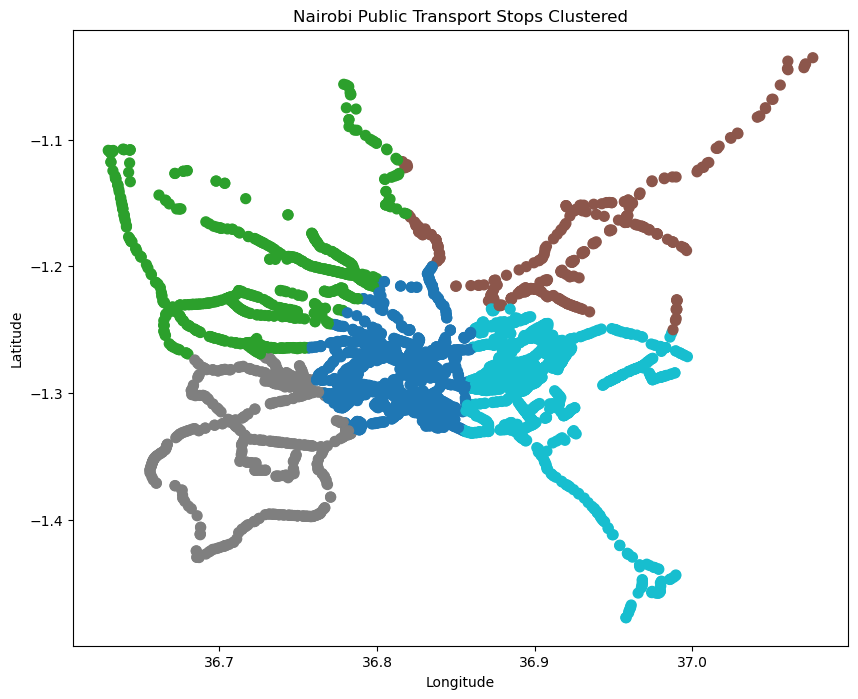

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select only lat/lon columns and drop NaNs if any
coords = stops[['stop_lat', 'stop_lon']].dropna()

# Try with k=5 clusters (you can tweak later)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(coords)

# Add cluster labels back to dataframe
stops['cluster'] = kmeans.labels_

# Plot clusters
plt.figure(figsize=(10, 8))
plt.scatter(stops['stop_lon'], stops['stop_lat'], c=stops['cluster'], cmap='tab10', s=50)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Nairobi Public Transport Stops Clustered')
plt.show()


In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)


In [9]:
print(stops['cluster'].value_counts())


cluster
0    1338
4    1321
1     691
3     581
2     342
Name: count, dtype: int64


In [10]:
!pip install folium


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 1.7 MB/s eta 0:00:00.6 MB/s eta 0:00:01


In [13]:
import sys
!{sys.executable} -m pip install folium


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [15]:
import sys
print(sys.executable)


/opt/conda/envs/anaconda-2024.02-py310/bin/python


In [16]:
!/opt/conda/envs/anaconda-2024.02-py310/bin/python -m pip install folium


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [1]:
import folium
from folium.plugins import MarkerCluster


In [4]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init='auto')


In [5]:
import zipfile
import pandas as pd

# Unzip GTFS file if needed
with zipfile.ZipFile("gtfs.zip", 'r') as zip_ref:
    zip_ref.extractall("gtfs_nairobi/")

# Load stops data
stops = pd.read_csv("gtfs_nairobi/stops.txt")

# Do clustering again
from sklearn.cluster import KMeans

X = stops[['stop_lat', 'stop_lon']]
kmeans = KMeans(n_clusters=5, random_state=0)
stops['cluster'] = kmeans.fit_predict(X)


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [6]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init='auto')
